In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline

In [8]:
from sklearn.datasets import load_iris

iris = load_iris()

In [9]:
iris.keys()

dict_keys(['data', 'target', 'frame', 'target_names', 'DESCR', 'feature_names', 'filename', 'data_module'])

In [10]:
df = pd.DataFrame(iris['data'], columns=iris['feature_names'])

In [11]:
df['target'] = iris['target']

In [12]:
df['flower_name'] = df.target.apply(lambda x: iris.target_names[x])

In [13]:
df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target,flower_name
0,5.1,3.5,1.4,0.2,0,setosa
1,4.9,3.0,1.4,0.2,0,setosa
2,4.7,3.2,1.3,0.2,0,setosa
3,4.6,3.1,1.5,0.2,0,setosa
4,5.0,3.6,1.4,0.2,0,setosa


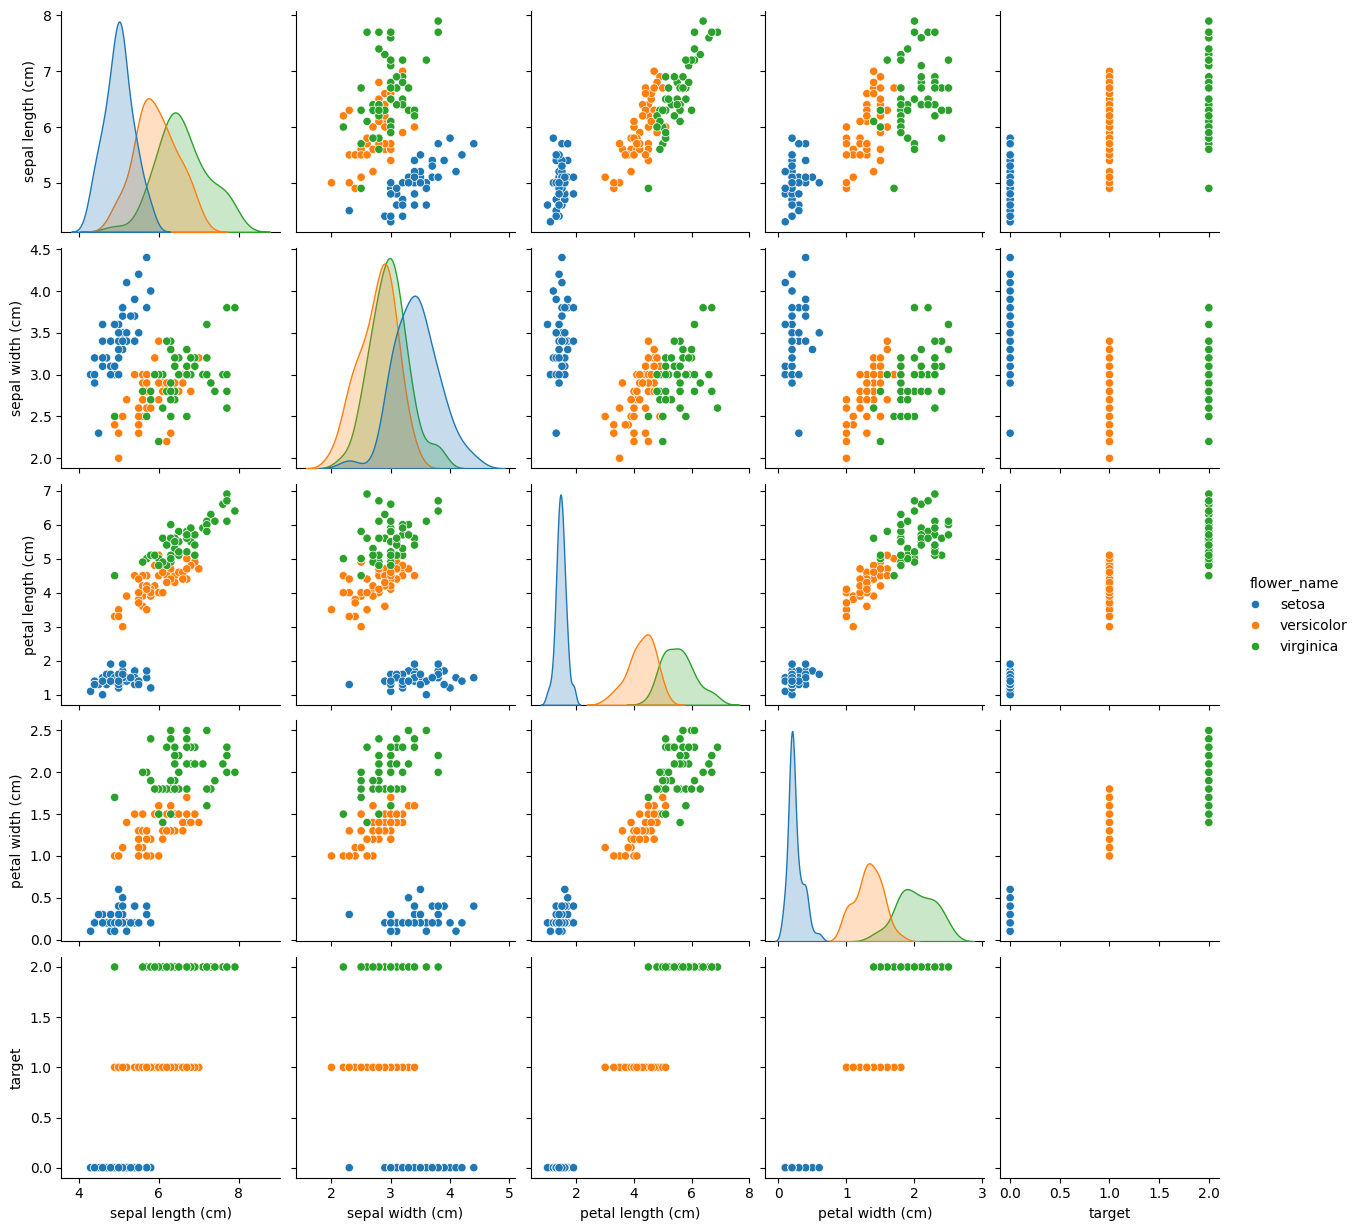

In [14]:
sns.pairplot(df, hue='flower_name')

<Axes: xlabel='sepal length (cm)', ylabel='sepal width (cm)'>

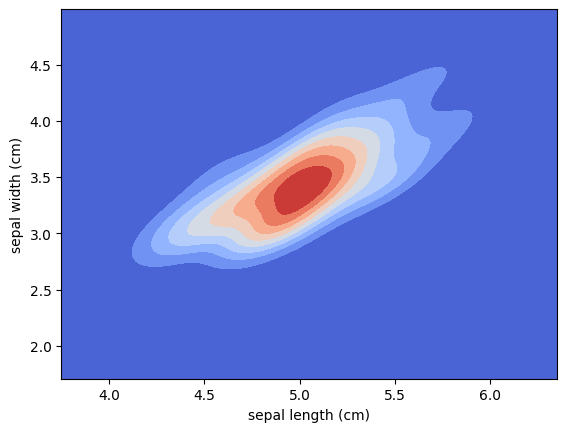

In [15]:
setosa = df[df['flower_name'] == 'setosa']

sns.kdeplot(
    x=setosa['sepal length (cm)'],
    y=setosa['sepal width (cm)'],
    cmap='coolwarm',
    fill=True,
    thresh=0
)

In [19]:
X = df.drop(['target', 'flower_name'], axis=1)
y = df['target']

In [20]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.30, random_state=101
)

In [21]:
from sklearn.svm import SVC

In [22]:
model = SVC()
model.fit(X_train, y_train)

SVC()

In [23]:
predictions = model.predict(X_test)

In [24]:
from sklearn.metrics import classification_report, confusion_matrix

In [25]:
print(confusion_matrix(y_test, predictions))

[[13  0  0]
 [ 0 19  1]
 [ 0  0 12]]


In [26]:
print(classification_report(y_test, predictions))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        13
           1       1.00      0.95      0.97        20
           2       0.92      1.00      0.96        12

    accuracy                           0.98        45
   macro avg       0.97      0.98      0.98        45
weighted avg       0.98      0.98      0.98        45



In [27]:
from sklearn.model_selection import GridSearchCV

In [28]:
param_grid = {
    'C': [0.1, 1, 10, 100],
    'gamma': [1, 0.1, 0.01, 0.001]
}

In [29]:
grid = GridSearchCV(SVC(), param_grid, refit=True, verbose=2)

In [30]:
grid.fit(X_train, y_train)

Fitting 5 folds for each of 16 candidates, totalling 80 fits
[CV] END .....................................C=0.1, gamma=1; total time=   0.0s
[CV] END .....................................C=0.1, gamma=1; total time=   0.0s
[CV] END .....................................C=0.1, gamma=1; total time=   0.0s
[CV] END .....................................C=0.1, gamma=1; total time=   0.0s
[CV] END .....................................C=0.1, gamma=1; total time=   0.0s
[CV] END ...................................C=0.1, gamma=0.1; total time=   0.0s
[CV] END ...................................C=0.1, gamma=0.1; total time=   0.0s
[CV] END ...................................C=0.1, gamma=0.1; total time=   0.0s
[CV] END ...................................C=0.1, gamma=0.1; total time=   0.0s
[CV] END ...................................C=0.1, gamma=0.1; total time=   0.0s
[CV] END ..................................C=0.1, gamma=0.01; total time=   0.0s
[CV] END ..................................C=0.1

GridSearchCV(estimator=SVC(),
             param_grid={'C': [0.1, 1, 10, 100],
                         'gamma': [1, 0.1, 0.01, 0.001]},
             verbose=2)

In [31]:
print(grid.best_params_)
print(grid.best_estimator_)

{'C': 1, 'gamma': 0.1}
SVC(C=1, gamma=0.1)


In [32]:
grid_predictions = grid.predict(X_test)

In [33]:
print(confusion_matrix(y_test, grid_predictions))

[[13  0  0]
 [ 0 19  1]
 [ 0  0 12]]


In [34]:
print(classification_report(y_test, grid_predictions))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        13
           1       1.00      0.95      0.97        20
           2       0.92      1.00      0.96        12

    accuracy                           0.98        45
   macro avg       0.97      0.98      0.98        45
weighted avg       0.98      0.98      0.98        45



In [35]:
# # The Iris Setosa
from IPython.display import Image, display
url = 'http://upload.wikimedia.org/wikipedia/commons/5/56/Kosaciec_szczecinkowaty_Iris_setosa.jpg'
display(Image(url=url, width=300, height=300))

In [36]:
# The Iris Versicolor
url = 'http://upload.wikimedia.org/wikipedia/commons/4/41/Iris_versicolor_3.jpg'
display(Image(url=url, width=300, height=300))

In [37]:
# The Iris Virginica
url = 'http://upload.wikimedia.org/wikipedia/commons/9/9f/Iris_virginica.jpg'
display(Image(url=url, width=300, height=300))